In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam


In [3]:
df = pd.read_csv("boston_house_prices.csv")


In [4]:
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


In [5]:
X = df.drop(columns=['PRICE'])   # Target column is MEDV (price)
y = df['PRICE']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 242.7068 - mae: 12.1886 - val_loss: 60.0900 - val_mae: 5.8344
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 38.4410 - mae: 4.6103 - val_loss: 34.8471 - val_mae: 3.9438
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.9287 - mae: 3.2757 - val_loss: 29.4062 - val_mae: 3.7546
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 15.8710 - mae: 2.9014 - val_loss: 28.8674 - val_mae: 3.7507
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13.8805 - mae: 2.6083 - val_loss: 26.1510 - val_mae: 3.5769
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.4498 - mae: 2.5109 - val_loss: 24.1841 - val_mae: 3.5137
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11.7199 - mae: 2.5083 - val_loss: 21.1797 - val_mae: 3.3397
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 10.9377 - mae: 2.4370 - val_loss: 24.3056 - val_mae: 3.4706
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0

In [11]:
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.5197 - mae: 2.1395
Test Loss (MSE): 9.51972770690918
Test MAE: 2.139538049697876


In [12]:
y_pred = model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [13]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})
print(comparison.head())


   Actual  Predicted
0    23.6  26.384007
1    32.4  34.169289
2    13.6  13.605716
3    22.8  23.744686
4    16.1  16.377113


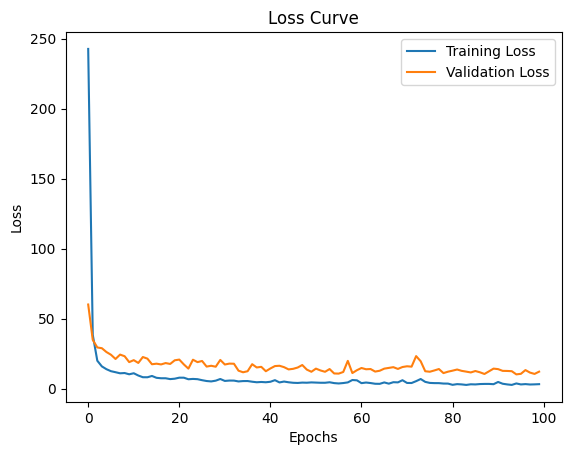

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()